In [1]:
from datasets import load_dataset

dataset = load_dataset("Teklia/IAM-line")

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 6482
    })
    validation: Dataset({
        features: ['image', 'text'],
        num_rows: 976
    })
    test: Dataset({
        features: ['image', 'text'],
        num_rows: 2915
    })
})


(np.float64(-0.5), np.float64(2466.5), np.float64(127.5), np.float64(-0.5))

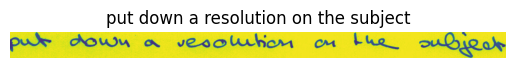

In [3]:
sample = dataset['train'][0]

import matplotlib.pyplot as plt

plt.imshow(sample['image'])
plt.title(sample['text'])
plt.axis('off')

In [4]:
print(type(sample['image']))
print(sample['text'])

<class 'PIL.JpegImagePlugin.JpegImageFile'>
put down a resolution on the subject


In [5]:
import cv2
import numpy as np

IMG_WIDTH = 512
IMG_HEIGHT = 32

def preprocess(image):
    image = np.array(image)

    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # resize
    image = cv2.resize(image, (IMG_WIDTH, IMG_HEIGHT))
    
    # normalize
    image = image / 255.0 
    
    return image

(np.float64(-0.5), np.float64(511.5), np.float64(31.5), np.float64(-0.5))

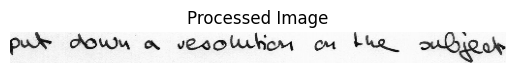

In [6]:
img = preprocess(dataset['train'][0]['image'])

import matplotlib.pyplot as plt
plt.imshow(img, cmap='gray')
plt.title("Processed Image")
plt.axis('off')

In [7]:
import string

characters = string.ascii_lowercase + string.digits + " "
char_to_idx = {c:i+1 for i,c in enumerate(characters)}  
idx_to_char = {i:c for c,i in char_to_idx.items()}

In [8]:
def encode(text):
    return [char_to_idx[c] for c in text if c in char_to_idx]

def decode(indices):
    return "".join([idx_to_char[i] for i in indices])

In [9]:
text = dataset['train'][0]['text'].lower()
encoded = encode(text)

print("Text:", text)
print("Encoded:", encoded[:10])

Text: put down a resolution on the subject
Encoded: [16, 21, 20, 37, 4, 15, 23, 14, 37, 1]


In [10]:
import torch
from torch.utils.data import Dataset

class IAMDataset(Dataset):
    def __init__(self, hf_dataset):
        self.data = hf_dataset
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        
        img = preprocess(item['image'])
        text = item['text'].lower()
        
        label = encode(text)
        
        img = torch.tensor(img).unsqueeze(0).float()
        label = torch.tensor(label)
        
        return img, label

In [11]:
def collate_fn(batch):
    images = []
    labels = []

    for img, label in batch:
        images.append(img)
        labels.append(label)

    images = torch.stack(images)  
    return images, labels        

In [ ]:
from torch.utils.data import DataLoader

train_dataset = IAMDataset(dataset['train'].select(range(3000)))

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn 
)

In [13]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels[0])

torch.Size([8, 1, 32, 512])
tensor([15,  6, 37, 20,  1, 11,  9, 14,  7, 37,  9, 20, 37, 15, 21, 20, 37, 15,
         6, 37, 20,  8,  5, 37, 16,  1, 20,  9,  5, 14, 20, 19, 37, 13, 18, 37,
        16, 15, 23,  5, 12, 12, 37, 19,  8, 15, 21, 12,  4])


In [14]:
import torch
import torch.nn as nn

class OCRModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # CNN
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )

        self.rnn = None
        self.fc = None
        self.num_classes = num_classes

    def forward(self, x):
        x = self.cnn(x)

        b, c, h, w = x.size()

        x = x.permute(0, 3, 1, 2)   
        x = x.reshape(b, w, c*h)    

        if self.rnn is None:
            input_size = x.size(2)
            print("Auto RNN input_size:", input_size)

            self.rnn = nn.LSTM(
                input_size,
                256,
                bidirectional=True,
                batch_first=True
            ).to(x.device)

            self.fc = nn.Linear(512, self.num_classes).to(x.device)

        x, _ = self.rnn(x)
        x = self.fc(x)

        return x

In [15]:
num_classes = len(char_to_idx) + 1  

model = OCRModel(num_classes)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [17]:
import torch.nn as nn

ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)  
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
for epoch in range(15):
    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)

        preds = model(images)
        preds = preds.log_softmax(2)
        preds = preds.permute(1, 0, 2)

        T = preds.size(0) 

        valid_images = []
        valid_labels = []

        for img, lab in zip(images, labels):
            if len(lab) > 0 :
                valid_images.append(img)
                valid_labels.append(lab)

        if len(valid_labels) == 0:
            continue

        images = torch.stack(valid_images).to(device)
        labels = valid_labels

        preds = model(images)
        preds = preds.log_softmax(2)
        preds = preds.permute(1, 0, 2)

        input_lengths = torch.full(
            size=(preds.size(1),),
            fill_value=preds.size(0),
            dtype=torch.long
        ).to(device)

        targets = torch.cat(labels).to(device)
        target_lengths = torch.tensor([len(l) for l in labels]).to(device)

        preds = preds.clamp(min=-10, max=10)
        ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)
        loss = ctc_loss(preds, targets, input_lengths, target_lengths)

        if torch.isnan(loss):
            continue

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 5)

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch} Loss: {total_loss:.4f}")

Auto RNN input_size: 512
Epoch 0 Loss: 1059.2316
Epoch 1 Loss: 911.3202
Epoch 2 Loss: 886.8251
Epoch 3 Loss: 876.4394
Epoch 4 Loss: 871.4228


In [19]:
def predict(image):
    model.eval()

    img = preprocess(image)
    img = torch.tensor(img).unsqueeze(0).unsqueeze(0).float().to(device)

    with torch.no_grad():
        pred = model(img)
        pred = pred.softmax(2)  
        pred = pred.argmax(2)

    pred = pred[0]

    result = []
    prev = -1

    for p in pred:
        p = p.item()
        if p != prev and p != 0:
            result.append(idx_to_char.get(p, ''))
        prev = p

    return "".join(result)

In [20]:
with open("output.txt", "w") as f:
    for i in range(5):
        img = dataset['test'][i]['image']
        
        pred = predict(img)
        actual = dataset['test'][i]['text']
        
        f.write(f"Pred: {pred}\n")
        f.write(f"Actual: {actual}\n")
        f.write("------\n")